# scWAT Xenium QC Region4
## Xiaonan Wang
## 18Aug2026

## Setup

### Parameters

Change `REGION_ID` for manual execution. Launchers inject the same parameters without editing the source notebook.

In [1]:
PROJECT_ROOT <- "/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium"
PIPELINE_REPO <- file.path(PROJECT_ROOT, "adipose_analysis", "YNH_Xenium_scWAT")
INPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_data")
REGION_ID <- "Region_4"
RUN_LABEL <- "full_notebook_qc_v2"
METADATA_PATH <- file.path(PIPELINE_REPO, "config", "scwat_sample_manifest.tsv")
EXPECTED_SECTION_COUNT <- 4L
SEED <- 20260814L
STRICT_MODE <- FALSE
EXTENDED_QC_MODE <- "AUTO"
EXTENDED_QC_CONFIG_PATH <- file.path(PIPELINE_REPO, "config", "extended_qc_defaults.tsv")

In [2]:
OUTPUT_ROOT <- file.path(PROJECT_ROOT, "adipose_analysis", "scwat_qc_outputs", RUN_LABEL)
SECTION_OUTPUT_DIR <- file.path(OUTPUT_ROOT, "sections", REGION_ID)

In [3]:
source(file.path(PIPELINE_REPO, "R", "source.R"))

In [4]:
for (package in c("Matrix", "jsonlite", "ggplot2")) require_package(package)

In [5]:
dir.create(SECTION_OUTPUT_DIR, recursive = TRUE, showWarnings = FALSE)
stopifnot(REGION_ID %in% paste0("Region_", seq_len(EXPECTED_SECTION_COUNT)))
cat("Section:", REGION_ID, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Section: Region_4 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4 


## Inputs

The selected raw/subset section directory is discovered by region ID. 

In [6]:
all_sections <- discover_xenium_sections(INPUT_ROOT, EXPECTED_SECTION_COUNT)

In [7]:
all_sections

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_1,1,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_1__20260805__124712
Region_2,2,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_2__20260805__124712
Region_3,3,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_3__20260805__124712
Region_4,4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


In [8]:
selected_section <- discover_one_section(INPUT_ROOT, REGION_ID)
selected_section

region_id,region_number,region_dir
<chr>,<int>,<chr>
Region_4,4,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


## Step1 - Configuration and metadata contract

In [9]:
if (nzchar(METADATA_PATH)) {
  assert_path_within(PROJECT_ROOT, METADATA_PATH)
  full_manifest <- utils::read.delim(METADATA_PATH, check.names = FALSE)
} else {
  full_manifest <- create_synthetic_manifest(all_sections$region_id, SEED)
}

In [10]:
full_manifest

tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes
<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>
scWAT,Region_1,Mouse_1,62308,Mouse_1,Region_1,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62308; no left/right factor
scWAT,Region_2,Mouse_1,62309,Mouse_1,Region_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62309; no left/right factor
scWAT,Region_3,Mouse_2,62310,Mouse_2,Region_3,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62310; no left/right factor
scWAT,Region_4,Mouse_2,62311,Mouse_2,Region_4,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62311; no left/right factor


In [11]:
# manifest_check <- validate_sample_manifest(full_manifest, all_sections$region_id)
# if (!manifest_check$valid) stop(paste(manifest_check$issues, collapse = "; "))

In [12]:
section_manifest <- full_manifest[full_manifest$region_id == REGION_ID, , drop = FALSE]
section_manifest$region_dir <- selected_section$region_dir

In [13]:
section_manifest

,tissue,region_id,mouse_id,section_id,biological_replicate_id,technical_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret,notes,region_dir
,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<chr>
4,scWAT,Region_4,Mouse_2,62311,Mouse_2,Region_4,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,Section 62311; no left/right factor,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


In [14]:
configuration <- data.frame(
  key = c("project_root", "pipeline_repo", "input_root", "output_root", "region_id", "run_label", "seed", "strict_mode"),
  value = c(PROJECT_ROOT, PIPELINE_REPO, INPUT_ROOT, OUTPUT_ROOT, REGION_ID, RUN_LABEL, SEED, STRICT_MODE)
)

In [15]:
configuration

key,value
<chr>,<chr>
project_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium
pipeline_repo,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/YNH_Xenium_scWAT
input_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data
output_root,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2
region_id,Region_4
run_label,full_notebook_qc_v2
seed,20260814
strict_mode,FALSE


In [16]:
environment <- data.frame(
  item = c("R_version", "platform", "tempdir", "Matrix", "jsonlite", "ggplot2"),
  value = c(R.version.string, R.version$platform, tempdir(), as.character(packageVersion("Matrix")), as.character(packageVersion("jsonlite")), as.character(packageVersion("ggplot2")))
)

In [17]:
environment

item,value
<chr>,<chr>
R_version,R version 4.5.3 (2026-03-11)
platform,x86_64-conda-linux-gnu
tempdir,/tmp/RtmpxVzcum
Matrix,1.7.6
jsonlite,2.0.0
ggplot2,4.0.3


## Step2 - Provenance, integrity, panel reconciliation, and QC gate

In [18]:
region_dir <- selected_section$region_dir[[1]]
inventory <- inventory_section_files(region_dir, REGION_ID, calculate_md5 = TRUE)

In [19]:
inventory

region_id,relative_path,exists,size_bytes,modified_utc,md5
<chr>,<chr>,<lgl>,<dbl>,<chr>,<chr>
Region_4,experiment.xenium,TRUE,2779,2026-08-13 14:42:31 UTC,60dcba001fee001fa5f642308b7087ac
Region_4,metrics_summary.csv,TRUE,2201,2026-08-13 14:42:31 UTC,81b2e101d2d01b37abb8614b0e892e03
Region_4,analysis_summary.html,TRUE,8928319,2026-08-13 14:41:27 UTC,f937dc2e62dc3fd5c1f92ce1f0423232
Region_4,gene_panel.json,TRUE,256874,2026-08-13 14:42:32 UTC,88b3b1dc6443d266a7419c2b129e31b7
Region_4,cells.csv.gz,TRUE,3073412,2026-08-13 14:41:28 UTC,5b73847a40cf45db24ce9402a0f64e6c
Region_4,cell_feature_matrix/features.tsv.gz,TRUE,4272,2026-08-13 15:25:38 UTC,231b8d63d874e627141148431cc661f8
Region_4,cell_feature_matrix/barcodes.tsv.gz,TRUE,227401,2026-08-13 15:25:39 UTC,552b1b5157e6f3810f7f28a70802d8b5
Region_4,cell_feature_matrix/matrix.mtx.gz,TRUE,14768750,2026-08-13 15:25:50 UTC,bb4d93a4499b8f9cb2b34f083be70e8e


In [20]:
# if (!all(inventory$exists)) stop(paste("Missing required files:", paste(inventory$relative_path[!inventory$exists], collapse = ", ")))

In [21]:
# check 
## matrix.mtx.gz
## features.tsv.gz
## barcodes.tsv.gz
## cells.csv.gz
integrity <- validate_section_integrity(region_dir, REGION_ID)

In [22]:
integrity

region_id,matrix_features,matrix_cells,matrix_nonzero,feature_rows,barcode_rows,cell_rows,duplicate_cell_ids,dimension_match
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>
Region_4,541,50330,3021419,541,50330,50330,0,TRUE


In [23]:
alarms <- extract_analysis_alarms(file.path(region_dir, "analysis_summary.html"))

In [24]:
alarms

,raw_value,formatted_value,raised,title,message,level,id
,<lgl>,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>
1,TRUE,True,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected


In [25]:
# Gene gene annotations - from yanan
signature <- utils::read.delim(file.path(PIPELINE_REPO, "config", "eos_gene_sets.tsv"), check.names = FALSE)
gene_sets <- setNames(signature$gene_set, signature$gene)

In [26]:
table(signature$gene_set)


     common  long_lived short_lived 
          7          46          47 

In [27]:
nrow(signature)

[1] 100

In [28]:
# from xenium output
installed_genes <- read_custom_panel_genes(file.path(region_dir, "gene_panel.json"))

In [29]:
length(installed_genes)

[1] 100

In [30]:
# check if all match
panel_reconciliation <- reconcile_panel(signature$gene, installed_genes, gene_sets)

In [31]:
table(panel_reconciliation$status)


MATCH 
  100 

In [32]:
features_preview <- read_xenium_features(file.path(region_dir, "cell_feature_matrix", "features.tsv.gz"))

In [33]:
head(features_preview)

,feature_id,feature_name,feature_type
,<chr>,<chr>,<chr>
1,ENSMUSG00000109644,0610005C13Rik,Gene Expression
2,ENSMUSG00000028441,1110017D15Rik,Gene Expression
3,ENSMUSG00000096001,2610528A11Rik,Gene Expression
4,ENSMUSG00000040412,5330417C22Rik,Gene Expression
5,ENSMUSG00000018451,6330403K07Rik,Gene Expression
6,ENSMUSG00000109321,A330076H08Rik,Gene Expression


In [34]:
dim(features_preview)

[1] 541   3

In [35]:
feature_type_summary <- as.data.frame(table(features_preview$feature_type), stringsAsFactors = FALSE)
names(feature_type_summary) <- c("feature_type", "n_features")

In [36]:
feature_type_summary

feature_type,n_features
<chr>,<int>
Gene Expression,479
Negative Control Codeword,41
Negative Control Probe,20
Unassigned Codeword,1


## Step3 - Sparse import and section-specific cell QC

In [37]:
# read in 
## features.tsv.gz
## barcodes.tsv.gz
## matrix.mtx.gz
## cells.csv.gz
xenium <- import_xenium_mex(region_dir)

In [38]:
head(xenium$cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,nucleus_count,segmentation_method
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
aaaagcob-1,aaaagcob-1,583.546,4108.320,285,0,0,0,0,0,285,56.12922,32.33188,1,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)
aaablghc-1,aaablghc-1,634.669,4120.598,352,0,0,0,0,0,352,185.36641,14.26938,1,Segmented by boundary stain (ATP1A1+CD45+E-Cadherin)


In [39]:
table(xenium$cells$segmentation_method)


Segmented by boundary stain (ATP1A1+CD45+E-Cadherin) 
                                                9212 
                   Segmented by interior stain (18S) 
                                               40096 
             Segmented by nucleus expansion of 5.0µm 
                                                1022 

In [40]:
table(xenium$cells$nucleus_count)


    0     1     2     3     4     5 
  589 49131   549    50     9     2 

In [41]:
xenium$raw_matrix_dimensions

features    cells  nonzero 
     541    50330  3021419

In [42]:
xenium$raw_matrix_dimensions[3]*100/(xenium$raw_matrix_dimensions[1]*xenium$raw_matrix_dimensions[2])

nonzero 
11.09652

                    nCount_Xenium
              lower ≤ value ≤ upper
                         AND
                   nFeature_Xenium
              lower ≤ value ≤ upper
                         ↓
                  qc_core_pass = TRUE

In [43]:
qc <- calculate_xenium_cell_qc(xenium$counts, xenium$cells, REGION_ID)
metadata_columns <- intersect(c("mouse_id", "side", "section_id", "biological_replicate_id", "genotype", "treatment", "condition", "age_weeks", "metadata_status", "do_not_interpret"), names(section_manifest))
for (column in metadata_columns) qc$cell_metadata[[column]] <- section_manifest[[column]][[1]]

In [44]:
qc$thresholds

,region_id,metric,lower,upper,value,method
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
method,Region_4,nCount_Xenium,1,865.5830,191.00000,median_minus_3MAD_plus_5MAD
method1,Region_4,nFeature_Xenium,1,186.0210,60.00000,median_minus_3MAD_plus_5MAD
method2,Region_4,cell_area,0,382.1763,93.29282,median_minus_5MAD_plus_5MAD
1,Region_4,control_fraction_cell,0,0.0500,0.00000,max_5pct_or_q99.5


In [45]:
head(qc$cell_metadata, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,qc_review_flag,mouse_id,section_id,biological_replicate_id,genotype,treatment,condition,age_weeks,metadata_status,do_not_interpret
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<lgl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<lgl>
aaaagcob-1,aaaagcob-1,583.546,4108.320,285,0,0,0,0,0,285,⋯,FALSE,Mouse_2,62311,Mouse_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE
aaablghc-1,aaablghc-1,634.669,4120.598,352,0,0,0,0,0,352,⋯,FALSE,Mouse_2,62311,Mouse_2,WT,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE


In [46]:
qc$summary

region_id,input_cells,core_qc_pass,core_qc_fail,review_flagged,nucleus_missing,multiple_nuclei,segmentation_multiplet,area_outlier,high_control,cells_deleted
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Region_4,50330,50140,190,1622,589,610,637,269,13,0


In [47]:
section_plots <- plot_section_qc(qc$cell_metadata, REGION_ID)

In [48]:
options(repr.plot.width=6, repr.plot.height=4)

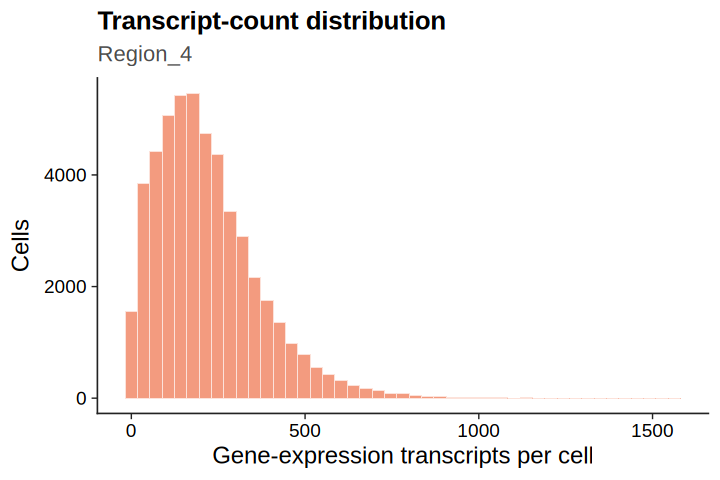

In [49]:
print(section_plots$counts)

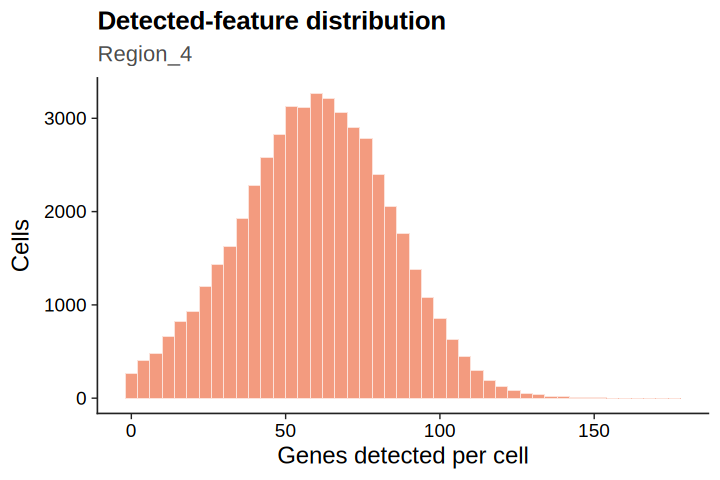

In [50]:
print(section_plots$features)

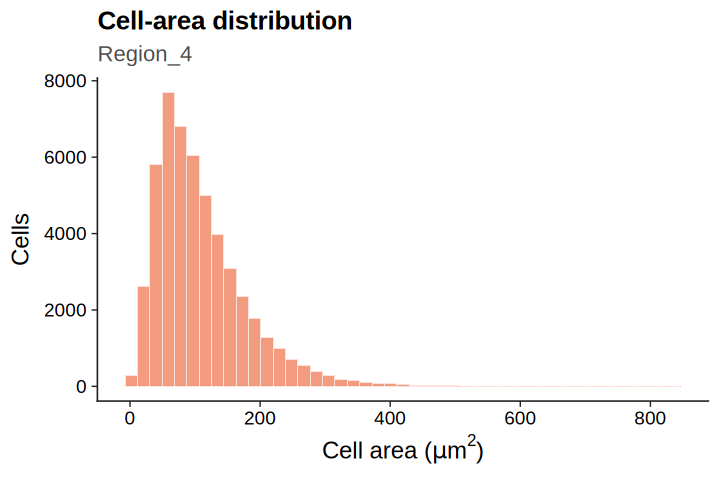

In [51]:
print(section_plots$area)

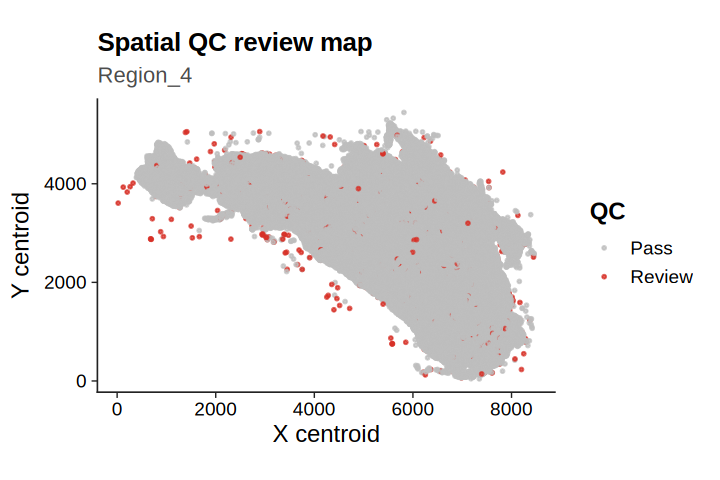

In [52]:
print(section_plots$spatial)

## Step4 - Cycle Alarm Check

In [53]:
extended_config <- read_extended_qc_config(EXTENDED_QC_CONFIG_PATH)

In [54]:
t(as.data.frame(extended_config))

qv_threshold,20.00
spatial_k,15.00
grid_size_um,100.00
permutations,999.00
dense_quantile,0.90
min_bin_cells,20.00
hotspot_fdr,0.05
candidate_abs_log2_ratio,0.50
candidate_abs_q20_delta,0.05
concordance_gene_spearman,0.90
concordance_review_rate_difference,0.05


In [55]:
extended_mode <- resolve_extended_qc_mode(EXTENDED_QC_MODE, region_dir)

In [56]:
extended_mode

[1] "FULL_HPC"

In [57]:
# check package availability
extended_preflight <- extended_qc_preflight(extended_mode, region_dir, extended_config)

In [58]:
extended_preflight

check,required,available,status,details,mode
<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>
transcripts_parquet,TRUE,TRUE,PASS,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712/transcripts.parquet,FULL_HPC
arrow,TRUE,TRUE,PASS,R package for projected Parquet aggregation,FULL_HPC
dplyr,TRUE,TRUE,PASS,R package for lazy Arrow grouping and aggregation,FULL_HPC
RANN,TRUE,TRUE,PASS,R package for scalable nearest-neighbour calculations,FULL_HPC


In [59]:
# if (extended_mode == "FULL_HPC" && any(extended_preflight$status == "FAIL")) {
#   stop(paste("FULL_HPC extended preflight failed:", paste(extended_preflight$check[extended_preflight$status == "FAIL"], collapse = ", ")))
# }

In [60]:
cycle_alarm_evidence <- build_cycle_alarm_evidence(alarms, REGION_ID)

In [61]:
cycle_alarm_evidence

,region_id,raised,title,message,level,id,evidence_status,cycle_identity_status,gene_effect_status
,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Region_4,TRUE,Poor quality imaging cycles detected,"A significant fraction of transcripts were missing from one or more imaging cycles. This could be caused by improper sample handling, insufficient reagent loading, high sample auto-fluorescence, or due to an algorithmic failure. This error may impact the quality score of transcripts from one or more genes. Please contact 10x support (support@10xgenomics.com) for diagnostics and troubleshooting.",ERROR,poor_quality_cycles_detected,DIRECT_EVIDENCE,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,GENE_EFFECT_UNCONFIRMED


In [62]:
cat("Extended mode:", extended_mode, "\nInput:", region_dir, "\nOutput:", SECTION_OUTPUT_DIR, "\n")

Extended mode: FULL_HPC 
Input: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712 
Output: /dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4 


## Step5 - Per-gene quality diagnostics

In [63]:
matrix_gene_quality <- summarise_gene_matrix_qc(xenium$counts, REGION_ID, gene_sets)

In [64]:
head(matrix_gene_quality,n=2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,Region_4,0610005C13Rik,NA,519,0.4745181,503,0.009994039,50330
2,Region_4,1110017D15Rik,NA,578,0.5284614,561,0.011146434,50330


In [65]:
extended_config$qv_threshold

[1] 20

In [66]:
# qv: qualiity value
# q20: qv >= qv_threshold, which = 20
if (extended_mode == "FULL_HPC") {
  transcript_gene_quality <- summarise_transcript_quality_arrow(file.path(region_dir, "transcripts.parquet"), REGION_ID, extended_config$qv_threshold)
  gene_quality <- combine_gene_quality(matrix_gene_quality, transcript_gene_quality)
} else {
  gene_quality <- matrix_gene_quality
  gene_quality$transcript_rows <- NA_integer_
  gene_quality$mean_qv <- NA_real_
  gene_quality$fraction_q20 <- NA_real_
  gene_quality$represented_codewords <- NA_integer_
  gene_quality$transcript_status <- "NOT_RUN_LOCAL_SUBSET"
}

In [67]:
head(transcript_gene_quality, n =2)

,region_id,gene,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<int>,<dbl>,<dbl>,<int>,<chr>
162,Region_4,0610005C13Rik,1214,22.38386,0.4975288,1,MEASURED_ARROW_PROJECTED_AGGREGATE
163,Region_4,1110017D15Rik,1185,22.61203,0.5156118,1,MEASURED_ARROW_PROJECTED_AGGREGATE


In [68]:
head(gene_quality, n = 2)

,region_id,gene,gene_set,raw_counts,counts_per_10000,detected_cells,detection_fraction,matrix_cells,transcript_rows,mean_qv,fraction_q20,represented_codewords,transcript_status
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<int>,<chr>
1,Region_4,0610005C13Rik,NA,519,0.4745181,503,0.009994039,50330,1214,22.38386,0.4975288,1,MEASURED_ARROW_PROJECTED_AGGREGATE
2,Region_4,1110017D15Rik,NA,578,0.5284614,561,0.011146434,50330,1185,22.61203,0.5156118,1,MEASURED_ARROW_PROJECTED_AGGREGATE


## Step6 - Spatial diagnostics

In [69]:
extended_config$grid_size_um

[1] 100

In [70]:
spatial_cells <- assign_spatial_grid(qc$cell_metadata, extended_config$grid_size_um)

In [71]:
dim(spatial_cells)

[1] 50330    39

In [72]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,treatment,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>
aaaagcob-1,aaaagcob-1,583.546,4108.320,285,0,0,0,0,0,285,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,5,40,5:40,FALSE,100
aaablghc-1,aaablghc-1,634.669,4120.598,352,0,0,0,0,0,352,⋯,None,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,6,40,6:40,FALSE,100


In [73]:
spatial_k <- min(as.integer(extended_config$spatial_k), nrow(spatial_cells) - 1L)

In [74]:
spatial_k

[1] 15

In [75]:
spatial_cells$local_density <- calculate_knn_density(spatial_cells, spatial_k, extended_mode)

In [76]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,condition,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>
aaaagcob-1,aaaagcob-1,583.546,4108.320,285,0,0,0,0,0,285,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,5,40,5:40,FALSE,100,0.003363822
aaablghc-1,aaablghc-1,634.669,4120.598,352,0,0,0,0,0,352,⋯,Normal,8,VERIFIED_USER_SUPPLIED,FALSE,6,40,6:40,FALSE,100,0.003413699


In [77]:
extended_config$dense_quantile

[1] 0.9

In [78]:
density_cutoff <- stats::quantile(spatial_cells$local_density, extended_config$dense_quantile, na.rm = TRUE)
spatial_cells$dense_aggregate <- spatial_cells$local_density >= density_cutoff

In [79]:
table(spatial_cells$dense_aggregate)


FALSE  TRUE 
45297  5033 

In [80]:
head(spatial_cells, n=2)

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,⋯,age_weeks,metadata_status,do_not_interpret,grid_x,grid_y,grid_id,edge_proxy,grid_size_um,local_density,dense_aggregate
,<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<lgl>,<int>,<int>,<chr>,<lgl>,<dbl>,<dbl>,<lgl>
aaaagcob-1,aaaagcob-1,583.546,4108.320,285,0,0,0,0,0,285,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,5,40,5:40,FALSE,100,0.003363822,FALSE
aaablghc-1,aaablghc-1,634.669,4120.598,352,0,0,0,0,0,352,⋯,8,VERIFIED_USER_SUPPLIED,FALSE,6,40,6:40,FALSE,100,0.003413699,FALSE


In [81]:
# if QC flags cluster together?
spatial_global <- test_spatial_flag_clustering(spatial_cells, spatial_k, extended_config$permutations, extended_config$seed, extended_mode)
spatial_global$region_id <- REGION_ID

In [82]:
spatial_global

status,statistic,empirical_p,permutations,k,seed,region_id
<chr>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
ESTIMATED,0.01965822,0.001,999,15,20260814,Region_4


QC-flagged cells in Region 4 are not randomly scattered, they are spatially clustered!

In [83]:
# check spatial enrichment
spatial_edge_density <- summarise_spatial_enrichment(spatial_cells)
spatial_edge_density$region_id <- REGION_ID

In [84]:
spatial_edge_density

class_type,class,cells,flagged,review_rate,risk_ratio,absolute_rate_difference,region_id
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
edge_proxy,edge,4555,247,0.05422613,1.8078764,0.024187895,Region_4
edge_proxy,interior,45775,1375,0.03003823,1.8078764,0.024187895,Region_4
local_density,dense,5033,123,0.02443870,0.7411162,-0.008653995,Region_4
local_density,non_dense,45297,1499,0.03309270,0.7411162,-0.008653995,Region_4


- cells near the tissue edge are about 80% more likely to be QC-flagged than interior cells -> a real edge effect, but the absolute increase is modest
- dense regions are protective with respect to QC flags, the flag rate is about 36% lower in dense areas than in non-dense areas

Thus, Region 4 QC flags are spatially non-random, with some enrichment near tissue edges, but they are not driven by dense cellular regions. The effect size is modest overall.

In [85]:
# find spatial hotspots
spatial_hotspots <- find_spatial_qc_hotspots(spatial_cells, extended_config$permutations, extended_config$min_bin_cells, extended_config$hotspot_fdr, extended_config$seed)
spatial_hotspots$region_id <- rep(REGION_ID, nrow(spatial_hotspots))

In [86]:
dim(spatial_hotspots)

[1] 1312   18

In [87]:
head(spatial_hotspots,n=2)

,grid_id,cells,flagged,review_rate,global_rate,rate_difference,empirical_p,adjusted_p,hotspot_status,x_min,x_max,y_min,y_max,fdr_threshold,min_bin_cells_threshold,permutations,seed,region_id
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
1,5:40,39,3,0.07692308,0.0322273,0.04469578,0.147,1,NO_HOTSPOT_EVIDENCE,522.1915,621.2203,4054.298,4142.428,0.05,20,999,20260814,Region_4
2,6:40,42,3,0.07142857,0.0322273,0.03920127,0.184,1,NO_HOTSPOT_EVIDENCE,627.9550,719.0001,4046.092,4139.993,0.05,20,999,20260814,Region_4


In [88]:
table(spatial_hotspots$hotspot_status)


NO_HOTSPOT_EVIDENCE 
               1312 

In [89]:
manual_review_manifest <- spatial_hotspots[spatial_hotspots$hotspot_status == "MORPHOLOGY_REVIEW_REQUIRED", , drop = FALSE]

In [90]:
dim(manual_review_manifest)

[1]  0 18

In [91]:
# if (!nrow(manual_review_manifest)) manual_review_manifest$review_note <- character() else manual_review_manifest$review_note <- "Inspect morphology/image for edge, fold, tear, or dense aggregate context"

In [92]:
extended_plots <- plot_extended_spatial_qc(spatial_cells, spatial_edge_density, spatial_hotspots, REGION_ID)

In [93]:
names(extended_plots)

[1] "review_map"   "edge_density" "hotspots"

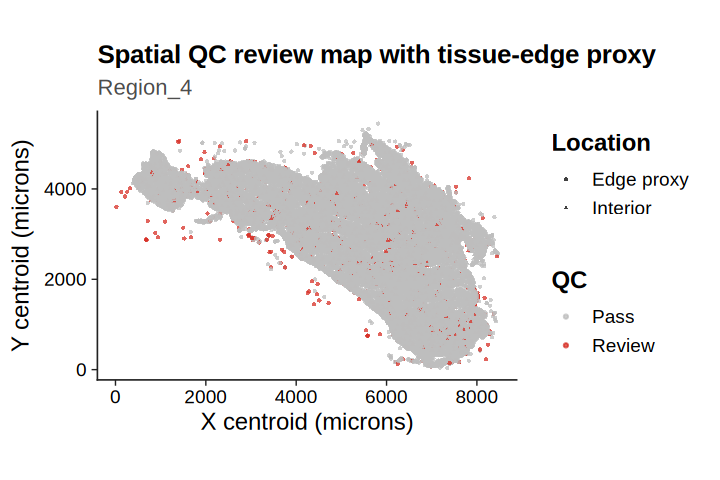

In [94]:
print(extended_plots$review_map)

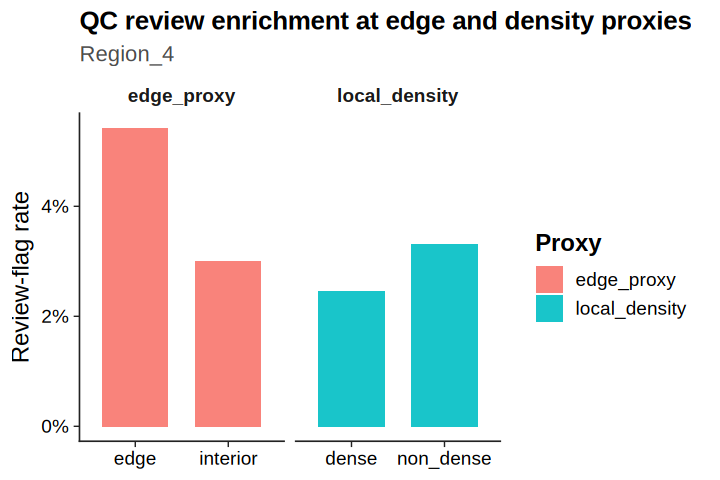

In [95]:
print(extended_plots$edge_density)

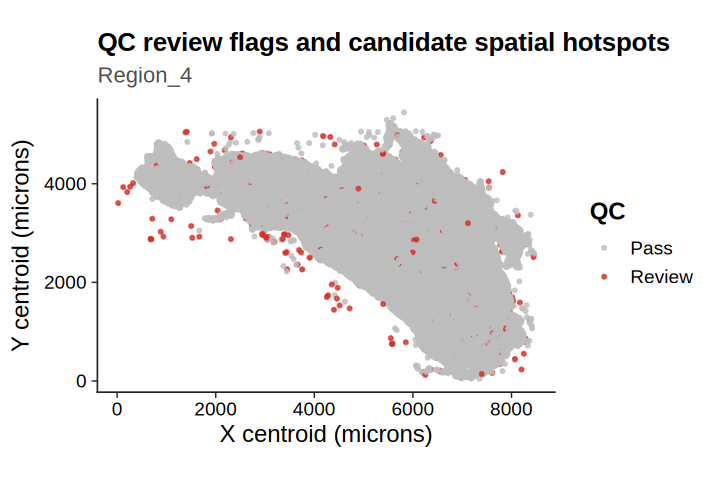

In [96]:
# there is no identified hotspots
print(extended_plots$hotspots)

## Step7 - Evidence-only downstream masks

Keep all cells, but flag with
- primary_include: passes the core QC and is not flagged as a segmentation multiplet or high-control cell
    - qc_core_pass
    - !segmentation_multiplet_flag
    - !high_control_flag
- strict_include: sensitivity1
    - primary_include
    - !nucleus missing
    - !area outlier
- hotspot_Sensitivity_include: sensitivity2
    - primary_include
    - !hotspot_flag

Primary_include would be used as the main downstream analysis

In [97]:
mask_provenance <- paste(RUN_LABEL, REGION_ID, extended_mode, normalizePath(region_dir, winslash = "/", mustWork = TRUE), sep = "|")

In [98]:
mask_provenance

[1] "full_notebook_qc_v2|Region_4|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712"

In [99]:
colnames(spatial_cells)

[1] "cell_id"                     "x_centroid"                 
 [3] "y_centroid"                  "transcript_counts"          
 [5] "control_probe_counts"        "genomic_control_counts"     
 [7] "control_codeword_counts"     "unassigned_codeword_counts" 
 [9] "deprecated_codeword_counts"  "total_counts"               
[11] "cell_area"                   "nucleus_area"               
[13] "nucleus_count"               "segmentation_method"        
[15] "region_id"                   "nCount_Xenium"              
[17] "nFeature_Xenium"             "control_fraction_cell"      
[19] "nucleus_missing_flag"        "multiple_nuclei_flag"       
[21] "cell_area_outlier_flag"      "high_control_flag"          
[23] "segmentation_multiplet_flag" "qc_core_pass"               
[25] "qc_review_flag"              "mouse_id"                   
[27] "section_id"                  "biological_replicate_id"    
[29] "genotype"                    "treatment"                  
[31] "condition"                   "age_weeks"                  
[33] "metadata_status"             "do_not_interpret"           
[35] "grid_x"                      "grid_y"                     
[37] "grid_id"                     "edge_proxy"                 
[39] "grid_size_um"                "local_density"              
[41] "dense_aggregate"

In [100]:
downstream_masks <- build_cell_downstream_masks(spatial_cells, spatial_hotspots, mask_provenance)

In [101]:
colnames(downstream_masks)

[1] "cell_id"                       "x_centroid"                   
 [3] "y_centroid"                    "transcript_counts"            
 [5] "control_probe_counts"          "genomic_control_counts"       
 [7] "control_codeword_counts"       "unassigned_codeword_counts"   
 [9] "deprecated_codeword_counts"    "total_counts"                 
[11] "cell_area"                     "nucleus_area"                 
[13] "nucleus_count"                 "segmentation_method"          
[15] "region_id"                     "nCount_Xenium"                
[17] "nFeature_Xenium"               "control_fraction_cell"        
[19] "nucleus_missing_flag"          "multiple_nuclei_flag"         
[21] "cell_area_outlier_flag"        "high_control_flag"            
[23] "segmentation_multiplet_flag"   "qc_core_pass"                 
[25] "qc_review_flag"                "mouse_id"                     
[27] "section_id"                    "biological_replicate_id"      
[29] "genotype"                      "treatment"                    
[31] "condition"                     "age_weeks"                    
[33] "metadata_status"               "do_not_interpret"             
[35] "grid_x"                        "grid_y"                       
[37] "grid_id"                       "edge_proxy"                   
[39] "grid_size_um"                  "local_density"                
[41] "dense_aggregate"               "primary_include"              
[43] "strict_include"                "hotspot_review_cell"          
[45] "hotspot_sensitivity_include"   "section_status"               
[47] "mask_rule_primary"             "mask_rule_strict"             
[49] "mask_rule_hotspot_sensitivity" "provenance"

In [102]:
table(downstream_masks$primary_include)


FALSE  TRUE 
  808 49522 

In [103]:
table(downstream_masks$strict_include)


FALSE  TRUE 
 1622 48708 

In [104]:
table(downstream_masks$hotspot_review_cell)


FALSE 
50330 

In [105]:
section_downstream_decision <- build_one_section_downstream_decision(
  downstream_masks, RUN_LABEL, extended_mode, mask_provenance,
  format(Sys.time(), tz = "UTC", usetz = TRUE)
)

In [106]:
section_downstream_decision

region_id,section_status,input_cells,primary_include_cells,primary_exclude_cells,strict_include_cells,strict_exclude_cells,hotspot_sensitivity_include_cells,hotspot_review_cells,cluster_discovery_eligible,⋯,region4_mapping_rule,primary_mask_rule,strict_mask_rule,hotspot_sensitivity_mask_rule,decision_rule,run_label,execution_mode,generated_utc,source_artifact,provenance
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Region_4,SENSITIVITY_ONLY,50330,49522,808,48708,1622,49522,0,FALSE,⋯,MAP_TO_FINAL_REGION_1_3_REFERENCE; LOW_CONFIDENCE=Uncertain,qc_core_pass AND NOT segmentation_multiplet_flag AND NOT high_control_flag,NOT qc_review_flag,primary_include AND NOT Region_3 morphology-review hotspot cell,Fixed evidence-only section decision approved 2026-08-15; masks annotate without deleting raw cells,full_notebook_qc_v2,FULL_HPC,2026-08-18 07:53:11 UTC,section cell and spatial QC artifacts,full_notebook_qc_v2|Region_4|FULL_HPC|/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_data/output-XETG00205__0104985__Region_4__20260805__124712


In [107]:
with(downstream_masks, c(primary_include = sum(primary_include), strict_include = sum(strict_include), hotspot_sensitivity_include = sum(hotspot_sensitivity_include)))

primary_include              strict_include 
                      49522                       48708 
hotspot_sensitivity_include 
                      49522

## Step8 - Final Checks

In [108]:
# Main outputs
# Cell QC metadata saved as cell_qc_metadata.tsv.gz
# full qc rds: region_id+.phase0_2_qc.rds
# sessionInfo: sessionInfo.txt
artifact_paths <- write_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID,
  configuration = configuration, manifest = section_manifest, environment = environment,
  inventory = inventory, integrity = integrity, feature_type_summary = feature_type_summary,
  panel_reconciliation = panel_reconciliation, alarms = alarms, qc = qc,
  counts = xenium$counts, features = xenium$features, strict_mode = STRICT_MODE
)

In [109]:
stopifnot(validate_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID))

In [110]:
readiness <- utils::read.delim(file.path(SECTION_OUTPUT_DIR, "section_readiness_gates.tsv"), check.names = FALSE)
readiness

gate,status,details
<chr>,<chr>,<chr>
required_files,PASS,0 missing required files
matrix_integrity,PASS,"Matrix, features, barcodes, and cells must align"
panel_reconciliation,PASS,0 missing/extra expected-panel entries
metadata,PASS,Synthetic metadata blocks biological interpretation
xenium_analysis_alerts,HOLD,1 alarms; 1 errors
overall,HOLD,Worst-case readiness across gates


In [111]:
# Cell metatable: spatial_qc_cell_annotations.tsv.gz
extended_artifact_paths <- write_extended_section_artifacts(
  project_root = PROJECT_ROOT, output_dir = SECTION_OUTPUT_DIR, region_id = REGION_ID, mode = extended_mode,
  preflight = extended_preflight, cycle_alarm_evidence = cycle_alarm_evidence, gene_quality = gene_quality,
  spatial_global = spatial_global, spatial_edge_density = spatial_edge_density, spatial_hotspots = spatial_hotspots,
  spatial_cells = spatial_cells, manual_review_manifest = manual_review_manifest, plots = extended_plots
)

In [112]:
stopifnot(validate_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode))

In [113]:
extended_reload <- read_extended_section_artifacts(SECTION_OUTPUT_DIR, REGION_ID, extended_mode)
stopifnot(nrow(extended_reload$spatial_cells) == nrow(qc$cell_metadata))

In [114]:
extended_reload$status

region_id,mode,transcript_status,diagnostic_status,cells,cells_deleted,cycle_identity_status,morphology_status
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
Region_4,FULL_HPC,COMPUTED,FULL_HPC_COMPLETE,50330,0,CYCLE_IDENTITY_UNRESOLVED_REQUIRES_10X,COORDINATE_DIAGNOSTICS_REQUIRE_IMAGE_REVIEW


In [115]:
section_mask_path <- write_gz_tsv(downstream_masks, file.path(SECTION_OUTPUT_DIR, "cell_downstream_masks.tsv.gz"), PROJECT_ROOT)
section_decision_path <- write_tsv(section_downstream_decision, file.path(SECTION_OUTPUT_DIR, "section_downstream_decision.tsv"), PROJECT_ROOT)
stopifnot(file.exists(section_mask_path), file.exists(section_decision_path))

## Outputs

All outputs are section-specific. The section notebook creates `cell_downstream_masks.tsv.gz` and `section_downstream_decision.tsv`

In [116]:
data.frame(artifact = basename(artifact_paths), path = artifact_paths)[seq_len(min(length(artifact_paths), 20L)), , drop = FALSE]
data.frame(artifact = basename(extended_artifact_paths), path = extended_artifact_paths)
cat("Completed", REGION_ID, "with", nrow(qc$cell_metadata), "cells; zero cells deleted. Extended mode:", extended_mode, "\n")

,artifact,path
,<chr>,<chr>
1,configuration.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/configuration.tsv
2,section_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/section_manifest.tsv
3,environment_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/environment_preflight.tsv
4,file_inventory.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/file_inventory.tsv
5,integrity_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/integrity_summary.tsv
6,feature_type_summary.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/feature_type_summary.tsv
7,panel_reconciliation.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/panel_reconciliation.tsv
8,analysis_alerts.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/analysis_alerts.tsv
9,qc_thresholds.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/qc_thresholds.tsv


artifact,path
<chr>,<chr>
extended_qc_preflight.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/extended_qc_preflight.tsv
cycle_alarm_evidence.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/cycle_alarm_evidence.tsv
gene_transcript_quality.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/gene_transcript_quality.tsv
spatial_qc_global.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/spatial_qc_global.tsv
spatial_qc_edge_density.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/spatial_qc_edge_density.tsv
spatial_qc_hotspots.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/spatial_qc_hotspots.tsv
spatial_manual_review_manifest.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/spatial_manual_review_manifest.tsv
spatial_qc_cell_annotations.tsv.gz,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/spatial_qc_cell_annotations.tsv.gz
extended_qc_status.tsv,/dssg/home/acct-svetoslav_chakarov/svetoslav_chakarov/Lab_members/Yanan_Hu/YNH_Xenium/adipose_analysis/scwat_qc_outputs/full_notebook_qc_v2/sections/Region_4/extended_qc_status.tsv


Completed Region_4 with 50330 cells; zero cells deleted. Extended mode: FULL_HPC 
